### author by yangshichen
### 注意：脚本仅供参考，使用前请仔细阅读

In [1]:
library(ggplot2)
library(future)
library(tidyverse)
library(ggpubr)
library(ggchicklet)
library(ggsci)
library(magrittr)
library(ggh4x)
library(rstatix)
library(ggsignif)
library(ggnewscale)
library(patchwork)
library(gapminder)
library(ggprism)
library(dplyr)
library(ggplotify)
library(readr)
library(arrow)
library(ggbreak)
library(org.Hs.eg.db)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

载入程序包：‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract



载入程序包：‘rstatix’


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘arrow’


The following object is masked from ‘package:magrittr’:

    is_in


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked from ‘package:utils’:

    timestamp


ggbreak v0.1.5 Learn more 

In [2]:
mytheme <- theme_prism(base_family="",base_fontface="plain") +
  theme(strip.text = element_text(size = 8,angle=10,vjust = 0.5,hjust = 0.5),
        axis.line = element_line(color = "black",size = 0.2),
        axis.ticks = element_line(size = 0.2),
        axis.text.y = element_text(color = "black",size = 6),
        axis.text.x = element_text(color = "black",size = 6, angle = 30,hjust = 1,vjust = 1),
        axis.title = element_text(color = "black",size = 10),
        legend.position = "none")

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


### 共享的顺式 eQTL 数量

#### 1kCN vs CIMA

In [3]:
OnekCN <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv', head =T)
OnekCN

X,X.1,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,⋯,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,celltype_level_pval_nominal_threshold,study_wise_qval,study_wise_nominal_threshold
<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,LINC01409,2098,1.014873,175.4605,633.2236,7.667730e-06,1:913469:G:C,134721,⋯,1.174355e-06,0.3765205,0.07683704,0.00119988,1.210901e-03,Adaptive NK cells,1.590819e-03,0.0003445664,3.700370e-03,1.377503e-04
2,1,LINC00115,2110,1.034240,184.2302,638.6180,1.084343e-18,1:913469:G:C,89240,⋯,1.345368e-21,0.7540356,0.07656465,0.00009999,5.709014e-17,Adaptive NK cells,2.350422e-16,0.0003494642,5.632009e-16,1.419710e-04
3,2,LINC01128,2155,1.033578,190.2563,638.3401,2.224656e-33,1:913469:G:C,88330,⋯,8.960126e-39,0.9652224,0.06992146,0.00009999,3.985215e-32,Adaptive NK cells,3.243837e-31,0.0003376822,7.682978e-31,1.371101e-04
6,5,PLEKHN1,2442,1.012655,203.7439,639.7712,9.955614e-06,1:967724:C:T,1241,⋯,1.803183e-06,0.2515789,0.05227502,0.00119988,1.863383e-03,Adaptive NK cells,2.363903e-03,0.0002945747,5.501332e-03,1.175416e-04
7,6,HES4,2544,1.040256,206.6732,632.9800,3.134341e-16,1:1000079:A:G,1116,⋯,7.069647e-19,0.5806572,0.06369613,0.00009999,1.874707e-14,Adaptive NK cells,6.650379e-14,0.0003175379,1.603061e-13,1.296284e-04
8,7,ISG15,2579,1.031593,217.5914,637.3262,1.278423e-08,1:1015903:C:T,14764,⋯,7.304698e-10,0.1901433,0.03046918,0.00009999,1.831833e-06,Adaptive NK cells,3.476263e-06,0.0002933993,8.237876e-06,1.189355e-04
10,9,C1orf159,2845,1.009523,256.2610,654.2985,9.117941e-05,1:1023789:G:C,-58030,⋯,2.900352e-05,-0.2388179,0.05676469,0.02209779,2.219327e-02,Adaptive NK cells,2.243731e-02,0.0002317901,4.951678e-02,9.224086e-05
11,10,TNFRSF18,2898,1.040453,221.8812,634.2929,4.812934e-52,1:1217733:G:A,14224,⋯,5.615811e-61,-0.7218388,0.03988647,0.00009999,1.096144e-51,Adaptive NK cells,1.675139e-50,0.0002959626,3.933917e-50,1.208391e-04
12,11,TNFRSF4,2913,1.052444,212.6466,626.4841,1.036046e-44,1:1217251:C:A,5924,⋯,5.620543e-53,-0.6538712,0.03936067,0.00009999,1.407439e-44,Adaptive NK cells,1.746132e-43,0.0003206232,4.087194e-43,1.321603e-04


In [4]:
OnekCN_pbmc <- subset(OnekCN, OnekCN$celltype %in% c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                                                     'LAMP3+ DC'))
OnekCN_neutrophils <- subset(OnekCN, OnekCN$celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                                            'Proliferative mLDNs'))

In [5]:
CIMA <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/CIMA.csv', head =T)
CIMA <- subset(CIMA, CIMA$analysis %in% c("cis-eQTL"))
CIMA

,X,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,slope,slope_se,pval_perm,pval_beta,celltype,study_wise_qval,study_wise_nominal_threshold,A1.ALT.effect.allele.,A2.REF.,analysis
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,0,LINC01128,2344,1.029518,146.58803,297.0967,6.708564e-08,chr1_814733,-10405,-10405,⋯,0.6244616,0.10313909,0.00009999,6.909136e-06,Atypical_Bm_ITGAX,6.252067e-05,9.086377e-05,T,A,cis-eQTL
2,1,UBE2J2,3402,1.049307,210.10033,294.1663,5.556540e-05,chr1_1329973,56088,56088,⋯,0.3519292,0.07831303,0.00769923,9.120395e-03,Atypical_Bm_ITGAX,4.137411e-02,6.940499e-05,G,GCGTGTGCCATGCA,cis-eQTL
3,2,SSU72,4096,1.053009,308.96730,300.3712,3.530564e-05,chr1_1538787,-36076,-36076,⋯,0.4173631,0.09141989,0.00729927,8.341344e-03,Atypical_Bm_ITGAX,3.839333e-02,4.798780e-05,G,A,cis-eQTL
4,3,SLC35E2B,4245,1.040838,317.42334,302.7886,6.500860e-14,chr1_1646352,-46443,-46443,⋯,-0.6878668,0.08075760,0.00009999,7.422213e-12,Atypical_Bm_ITGAX,1.377836e-10,4.421236e-05,C,A,cis-eQTL
5,4,CDK11A,4245,1.061452,303.00452,297.5697,4.930235e-05,chr1_1687061,-37296,-37296,⋯,-0.2805065,0.06234498,0.00899910,1.114399e-02,Atypical_Bm_ITGAX,4.876636e-02,5.079840e-05,T,C,cis-eQTL
6,5,SLC35E2A,4245,1.031444,332.26532,304.9197,2.041432e-18,chr1_1660318,-85681,-85681,⋯,0.7051534,0.06994368,0.00009999,2.231382e-16,Atypical_Bm_ITGAX,6.097264e-15,4.045071e-05,T,C,cis-eQTL
7,6,CEP104,5730,1.053672,524.15173,309.9714,7.046991e-19,chr1_3813871,-43343,-43343,⋯,-0.5863563,0.05781302,0.00009999,5.357085e-17,Atypical_Bm_ITGAX,1.532077e-15,2.837210e-05,C,T,cis-eQTL
8,7,C1orf174,5796,1.039989,497.33353,307.2871,5.461152e-09,chr1_3887191,-13102,-13102,⋯,0.3982564,0.06172594,0.00009999,1.598832e-06,Atypical_Bm_ITGAX,1.590033e-05,2.811018e-05,C,T,cis-eQTL
9,8,UQCRHL,2981,1.045385,231.19757,304.3138,5.596262e-05,chr1_16370539,561191,561191,⋯,-0.3255105,0.07374086,0.00999900,1.034565e-02,Atypical_Bm_ITGAX,4.587640e-02,6.196658e-05,AT,A,cis-eQTL


In [6]:
genes1 <- na.omit(unique(OnekCN_pbmc$phenotype_id))
genes2 <- na.omit(unique(CIMA$phenotype_id))

In [7]:
library(VennDiagram)
library(grid)

pdf("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/venn_OnekCN_pbmc_CIMA.pdf")
venn_plot <- venn.diagram(
  x = list(OnekCN_pbmc = genes1, CIMA = genes2),
  filename = NULL,
  fill = c("#98B1B8", "#DECDB4"),
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
  cat.pos = 0,
  cat.dist = 0.05,
  margin = 0.05
)
grid.draw(venn_plot)
dev.off()

载入需要的程序包：grid

载入需要的程序包：futile.logger


载入程序包：‘VennDiagram’


The following object is masked from ‘package:ggpubr’:

    rotate




pdf 
  2

#### 1kCN vs AIDA

In [8]:
AIDA <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/AIDA.csv', head =T)
AIDA

AIDA_CellTypeAnnotation,Genetic.variant,Gene,eQTL_beta,eQTL_t.stat,eQTL_p.value,eQTL_CellSubtype_FDR,eigenMT_pvalue,eigenMT_tests,eigenMT_FDR
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
atypical_B,chr19_58381157_A_G,A1BG,0.11847884,3.470543,0.000732277,0.46075546,0.010251874,14,0.025252101
atypical_B,chr2_68648446_C_T,AAK1,-0.09665550,-3.296050,0.001304405,0.56525115,0.032610137,25,0.048479261
atypical_B,chr20_35603707_T_C,AAR2,-0.10845093,-4.037818,0.000097600,0.16105356,0.001074143,11,0.006708309
atypical_B,chr6_44038354_G_T,AARS2,0.04513283,3.357973,0.001065273,0.52914764,0.019174915,18,0.035502494
atypical_B,chr17_43891933_A_C,AARSD1,0.10401910,3.621491,0.000437143,0.37035977,0.005245720,12,0.017653370
atypical_B,chr17_36865248_G_A,AATF,0.06315616,3.194084,0.001810253,0.62010009,0.027153791,15,0.043370191
atypical_B,chr9_104400392_TCTGC_T,ABCA1,0.12086823,3.961510,0.000129570,0.19427184,0.003368822,26,0.013774346
atypical_B,chr9_137380007_C_T,ABCA2,-0.06074164,-3.090780,0.002504518,0.66685845,0.032558739,13,0.048428895
atypical_B,chr16_3215428_G_C,ABCA3,0.02333491,3.572209,0.000518193,0.40146864,0.010882054,21,0.026084900


In [9]:
length(unique(AIDA$Gene))

[1] 12117

In [10]:
genes1 <- na.omit(unique(OnekCN_pbmc$phenotype_id))
genes2 <- na.omit(unique(AIDA$Gene))

In [11]:
library(VennDiagram)
library(grid)

pdf("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/venn_OnekCN_pbmc_AIDA.pdf")
venn_plot <- venn.diagram(
  x = list(OnekCN_pbmc = genes1, AIDA = genes2),
  filename = NULL,
  fill = c("#98B1B8", "#9394A5"),
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
  cat.pos = 0,
  cat.dist = 0.05,
  margin = 0.05
)
grid.draw(venn_plot)
dev.off()

pdf 
  2

#### 1kCN vs OneK1K

In [12]:
Onek1k <- read.delim('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/Onek1k.tsv', head =T)
Onek1k

CELL_ID,CELL_TYPE,RSID,SNPID,GENE,GENE_ID,CHR,POS,A1,A2,A2_FREQ_ONEK1K,A2_FREQ_HRC,SPEARMANS_RHO,S_STATISTICS,P_VALUE,Q_VALUE,FDR,RSQUARE,GENOTYPED,ROUND
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
cd4nc,CD4 Naive/Central memory T cell,rs79010578,1:736289_A,RP11-206L10.9,ENSG00000237491,1,736289,T,A,0.12816,0.1388820,0.1354816,136444808,2.045940e-05,2.828026e-03,2.523829e-02,0.84779,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs1891906,1:950243_C,ISG15,ENSG00000187608,1,950243,A,C,0.38599,0.3814290,0.3327021,105317985,8.252290e-27,1.156738e-23,2.384248e-06,0.95444,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs57260149,1:1140290_C,TNFRSF18,ENSG00000186891,1,1140290,T,C,0.05728,0.0589313,-0.1740004,185289578,4.074417e-08,9.655409e-06,1.784878e-04,0.95654,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs307346,1:1260733_C,GLTPD1,ENSG00000224051,1,1260733,A,C,0.94924,0.9373730,-0.1771180,185781627,2.303768e-08,5.656051e-06,3.573890e-05,0.99485,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs2936661,1:1300946_A,MRPL20,ENSG00000242485,1,1300946,G,A,0.84303,0.8195570,-0.1825076,186632255,8.392422e-09,2.184810e-06,2.384248e-06,0.97300,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs904586,1:1430584_C,ATAD3C,ENSG00000215915,1,1430584,T,C,0.08355,0.1120730,0.1307779,137187175,3.946017e-05,5.042102e-03,3.822900e-02,0.82905,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs12735861,1:1562895_T,MIB2,ENSG00000197530,1,1562895,C,T,0.57763,0.5749770,-0.2440818,196350355,8.721559e-15,5.160831e-12,2.384248e-06,0.85902,Imputed,1
cd4nc,CD4 Naive/Central memory T cell,rs9442411,1:1619767_T,CDK11A,ENSG00000008128,1,1619767,C,T,0.20627,0.1865260,-0.1480648,181196226,3.166954e-06,5.358130e-04,5.284723e-03,0.99706,Genotyped,1
cd4nc,CD4 Naive/Central memory T cell,rs9442411,1:1619767_T,MMP23B,ENSG00000189409,1,1619767,C,T,0.20627,0.1865260,-0.1378395,179582392,1.459834e-05,2.093437e-03,1.971423e-02,0.99706,Genotyped,1


In [13]:
genes1 <- na.omit(unique(OnekCN_pbmc$phenotype_id))
genes2 <- na.omit(unique(Onek1k$GENE))

In [14]:
library(VennDiagram)
library(grid)

pdf("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/venn_OnekCN_pbmc_Onek1k.pdf")
venn_plot <- venn.diagram(
  x = list(OnekCN_pbmc = genes1, Onek1k = genes2),
  filename = NULL,
  fill = c("#98B1B8", "#E7E5A9"),
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
  cat.pos = 0,
  cat.dist = 0.05,
  margin = 0.05
)
grid.draw(venn_plot)
dev.off()

pdf 
  2

#### 1kCN vs EUR101

In [15]:
EUR101 <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/EUR101.csv', head =T)
EUR101

rsID,Chromosome,Position,REF,ALT,gene,statistic,pvalue,FDR,beta,R2..Var.explained.,genename
<chr>,<int>,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
rs1000431,1,27898603,C,A,3420561,11.311591,1.45000e-18,9.820000e-15,0.40358205,0.5017370,RPA2
rs10012416,4,1330558,G,A,4210653,9.307637,1.43000e-14,3.740000e-11,0.55616988,0.4554239,CRIPAK
rs10014278,4,83246831,C,T,630619,-4.397734,3.19000e-05,8.702704e-03,-0.21150090,0.1573368,HPSE
rs10026792,4,2860463,G,A,3870577,-4.164332,7.53000e-05,1.757067e-02,-0.07925069,0.1536241,MFSD10
rs10034537,4,87370995,G,A,6280008,3.976213,1.47690e-04,3.012252e-02,0.20839852,0.1258485,HSD17B11
rs10035183,5,177057983,A,G,2970121,4.081650,1.01461e-04,2.238584e-02,0.16663953,0.1467309,MXD3
rs10039522,5,96655165,G,A,3990112,5.916526,6.90000e-08,4.160000e-05,0.18296225,0.2578683,CAST
rs10047656,12,129140724,G,A,6650465,3.829310,2.46786e-04,4.473485e-02,0.21435939,0.1289934,SLC15A4
rs10051822,5,177308186,G,C,6590669,4.060126,1.09594e-04,2.383356e-02,0.11084957,0.1431211,RAB24


In [16]:
genes1 <- na.omit(unique(OnekCN_neutrophils$phenotype_id))
genes2 <- na.omit(unique(EUR101$genename))

In [17]:
library(VennDiagram)
library(grid)

pdf("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/venn_OnekCN_neu_EUR101.pdf")
venn_plot <- venn.diagram(
  x = list(OnekCN_neu = genes1, EUR101 = genes2),
  filename = NULL,
  fill = c("#81B2A0", "#CB8974"),
  alpha = 0.5,
  cex = 1.5,
  cat.cex = 1.5,
  cat.pos = 0,
  cat.dist = 0.05,
  margin = 0.05
)
grid.draw(venn_plot)
dev.off()

pdf 
  2

### π1 统计量，用于量化细胞类型之间 eQTL 共享的程度

#### 计算OnekCN nominal

In [3]:
# 1. 设置主文件夹路径
main_dir <- "/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL/"

# 2. 获取所有子文件夹
sub_dirs <- list.dirs(main_dir, recursive = FALSE)
sub_dirs <- sub_dirs[!grepl("\\.ipynb_checkpoints$", sub_dirs)]

# 3. 读取每个子文件夹下的 parquet 文件并添加 celltype 列
read_parquet_with_celltype <- function(folder) {
  # 获取该文件夹下所有 parquet 文件
  parquet_files <- list.files(folder, pattern = "\\.parquet$", full.names = TRUE)
  
  # 读取并合并 parquet 文件
  if(length(parquet_files) == 0) return(NULL)
  
  df <- map_dfr(parquet_files, ~read_parquet(.x))
  
  # 添加 celltype 列，使用子文件夹名
  df <- df %>% mutate(celltype = basename(folder))
  return(df)
}

# 4. 对所有子文件夹执行
all_data <- map_dfr(sub_dirs, read_parquet_with_celltype)

In [4]:
all_data

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
LINC01409,1:13868:A:G,-764880,-796197,0.3509203,466,572,0.719949610,0.016571999,0.04620511,Adaptive NK cells
LINC01409,1:16949:A:C,-761799,-793116,0.1300613,202,212,0.006607088,0.184615016,0.06778197,Adaptive NK cells
LINC01409,1:19342:G:A,-759406,-790723,0.1196319,185,195,0.534557133,-0.044231102,0.07118517,Adaptive NK cells
LINC01409,1:20250:T:C,-758498,-789815,0.2766871,391,451,0.923259040,-0.004796471,0.04977562,Adaptive NK cells
LINC01409,1:54421:A:G,-724327,-755644,0.1404908,212,229,0.601481950,0.033693533,0.06448608,Adaptive NK cells
LINC01409,1:57158:G:C,-721590,-752907,0.1257669,202,205,0.391574944,-0.060845092,0.07097606,Adaptive NK cells
LINC01409,1:58176:G:A,-720572,-751889,0.3484662,472,568,0.273204149,0.051493272,0.04696058,Adaptive NK cells
LINC01409,1:59193:T:G,-719555,-750872,0.1429448,217,233,0.548174844,0.038880724,0.06471806,Adaptive NK cells
LINC01409,1:59615:C:T,-719133,-750450,0.1478528,224,241,0.500207779,0.043000329,0.06375225,Adaptive NK cells


In [5]:
OnekCN_pbmc <- subset(all_data, all_data$celltype %in% c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                                                       'LAMP3+ DC'))
OnekCN_neutrophils <- subset(all_data, all_data$celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                                              'Proliferative mLDNs'))

In [6]:
OnekCN_pbmc

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
LINC01409,1:13868:A:G,-764880,-796197,0.3509203,466,572,0.719949610,0.016571999,0.04620511,Adaptive NK cells
LINC01409,1:16949:A:C,-761799,-793116,0.1300613,202,212,0.006607088,0.184615016,0.06778197,Adaptive NK cells
LINC01409,1:19342:G:A,-759406,-790723,0.1196319,185,195,0.534557133,-0.044231102,0.07118517,Adaptive NK cells
LINC01409,1:20250:T:C,-758498,-789815,0.2766871,391,451,0.923259040,-0.004796471,0.04977562,Adaptive NK cells
LINC01409,1:54421:A:G,-724327,-755644,0.1404908,212,229,0.601481950,0.033693533,0.06448608,Adaptive NK cells
LINC01409,1:57158:G:C,-721590,-752907,0.1257669,202,205,0.391574944,-0.060845092,0.07097606,Adaptive NK cells
LINC01409,1:58176:G:A,-720572,-751889,0.3484662,472,568,0.273204149,0.051493272,0.04696058,Adaptive NK cells
LINC01409,1:59193:T:G,-719555,-750872,0.1429448,217,233,0.548174844,0.038880724,0.06471806,Adaptive NK cells
LINC01409,1:59615:C:T,-719133,-750450,0.1478528,224,241,0.500207779,0.043000329,0.06375225,Adaptive NK cells


In [7]:
OnekCN_neutrophils

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
LINC01409,1:13868:A:G,-764880,-796197,0.3467456,481,586,0.95130062,0.0029966952,0.04905113,ALPL- MARCKS- NDNs
LINC01409,1:16949:A:C,-761799,-793116,0.1278107,206,216,0.06953613,0.1323362440,0.07281499,ALPL- MARCKS- NDNs
LINC01409,1:19342:G:A,-759406,-790723,0.1183432,190,200,0.95934296,-0.0037925104,0.07437088,ALPL- MARCKS- NDNs
LINC01409,1:20250:T:C,-758498,-789815,0.2769231,405,468,0.84240332,0.0104769524,0.05267797,ALPL- MARCKS- NDNs
LINC01409,1:54421:A:G,-724327,-755644,0.1390533,217,235,0.69067802,-0.0272205286,0.06837895,ALPL- MARCKS- NDNs
LINC01409,1:57158:G:C,-721590,-752907,0.1272189,212,215,0.89796043,0.0097886454,0.07630675,ALPL- MARCKS- NDNs
LINC01409,1:58176:G:A,-720572,-751889,0.3473373,490,587,0.48103575,-0.0355024710,0.05035975,ALPL- MARCKS- NDNs
LINC01409,1:59193:T:G,-719555,-750872,0.1414201,222,239,0.63844928,-0.0320551358,0.06819477,ALPL- MARCKS- NDNs
LINC01409,1:59615:C:T,-719133,-750450,0.1461539,229,247,0.77458762,-0.0192876048,0.06732641,ALPL- MARCKS- NDNs


#### OnekCN_pbmc VS CIMA

In [8]:
OnekCN_pbmc$L1 <- OnekCN_pbmc$celltype
ilc_types <- c("Adaptive NK cells","CD56bright NK cells","CD56dim NK cells","Proliferative NK cells","CILCP","CLP","ILC2","ILCP")
cd4_types <- c('CD27+ Th1','CD27+ Th17','CD27- Th1','CD27- Th17','CD4+ Temra','GZMB+ CD4+ terminal effector T cells','HLA-DRhi CD4+ terminal effector T cells','HLA-DRhi CD4+ Treg','KLRB1+ CD4+ Treg','Memory CD4+ Treg','Naïve CD4+ T cells','Naïve CD4+ Treg','Proliferative CD4+ Treg','Proliferative cytotoxic CD4+ T cells','Proliferative help memory T cells','Tfh','Th1_Th17','Th2','Th22')
cd8_types <- c('CCR4+ CD8+ Tcm','CCR4- CD8+ Tcm','CD27+ MAIT','CD27- MAIT','CD56+ MAIT','CD62Lhi GZMK+ Vδ2+ T cells','CD8+ Temra','CD8+ Treg','DN T cells','GZMB+ CD8+ Tem','GZMB+ Vδ2+ T cells','GZMK+ CD8+ Tem','GZMK+ effector Vδ1+ T cells','GZMK+ Vδ2+ T cells','HLA-DRhi CD8+ Tem','KLRC2+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','iNKT','Proliferative CD8+ memory T cells','Naïve CD8+ T cells','Naïve Vδ1+ T cells','Proliferative DN T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','vNKT')
b_types <- c('Atypical naïve B cells','Early memory B cells','CD27+ IgD+ atypical memory B cells','CD27+ IgD- atypical memory B cells','CD27- IgD- atypical memory B cells','Naïve B cells','CD95 memory B cells','IGKChi Plasma cells','IGLL5hi Plasma cells','Non-switched memory B cells','Plamsablasts','Switched Memory B cells')
myeloid_types <- c('ASDC','CD14+ cDC2','CD1C+ cDC2','cDC1','Core classical monocytes','GBP1+ classical monocytes','Intermediate monocytes','ISG+ classical monocytes','LAMP3+ DC','Non-classical monocytes','pDCs','MC_MCP','MEP','MkP','Platelets')

OnekCN_pbmc$L1 <- ifelse(OnekCN_pbmc$L1 %in% ilc_types,"ILC", OnekCN_pbmc$L1)
OnekCN_pbmc$L1 <- ifelse(OnekCN_pbmc$L1 %in% cd4_types,"CD4 T", OnekCN_pbmc$L1)
OnekCN_pbmc$L1 <- ifelse(OnekCN_pbmc$L1 %in% cd8_types,"CD8 T", OnekCN_pbmc$L1)
OnekCN_pbmc$L1 <- ifelse(OnekCN_pbmc$L1 %in% b_types,"B", OnekCN_pbmc$L1)
OnekCN_pbmc$L1 <- ifelse(OnekCN_pbmc$L1 %in% myeloid_types,"Myeloid", OnekCN_pbmc$L1)

OnekCN_pbmc

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype,L1
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
LINC01409,1:13868:A:G,-764880,-796197,0.3509203,466,572,0.719949610,0.016571999,0.04620511,Adaptive NK cells,ILC
LINC01409,1:16949:A:C,-761799,-793116,0.1300613,202,212,0.006607088,0.184615016,0.06778197,Adaptive NK cells,ILC
LINC01409,1:19342:G:A,-759406,-790723,0.1196319,185,195,0.534557133,-0.044231102,0.07118517,Adaptive NK cells,ILC
LINC01409,1:20250:T:C,-758498,-789815,0.2766871,391,451,0.923259040,-0.004796471,0.04977562,Adaptive NK cells,ILC
LINC01409,1:54421:A:G,-724327,-755644,0.1404908,212,229,0.601481950,0.033693533,0.06448608,Adaptive NK cells,ILC
LINC01409,1:57158:G:C,-721590,-752907,0.1257669,202,205,0.391574944,-0.060845092,0.07097606,Adaptive NK cells,ILC
LINC01409,1:58176:G:A,-720572,-751889,0.3484662,472,568,0.273204149,0.051493272,0.04696058,Adaptive NK cells,ILC
LINC01409,1:59193:T:G,-719555,-750872,0.1429448,217,233,0.548174844,0.038880724,0.06471806,Adaptive NK cells,ILC
LINC01409,1:59615:C:T,-719133,-750450,0.1478528,224,241,0.500207779,0.043000329,0.06375225,Adaptive NK cells,ILC


In [9]:
CIMA <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/CIMA.csv', head =T)
CIMA <- subset(CIMA, CIMA$analysis %in% c("cis-eQTL"))

CIMA$L1 <- CIMA$celltype
b_types <- c('Atypical_Bm_ITGAX','Bn_IFIT3','Bn_TCL1A','Bn_IL6','Plasma_IGHA1','Plasma_IGHG1','Plasmablast_MKI67','Switched_Bm_IGHE','Switched_activated_Bm_CD86','Switched_Bm_IGHDneg','Transitional_B_MME','Unswitched_Bm_CD1C','Unswitched_Bm_IL6','pre-Switched_Bm_JAM3')
cd4_types <- c('CD4_CTL_GZMH','CD4_Tcm_CXCR5','CD4_Tcm_IFI44L','CD4_Tem_CCR7neg','CD4_Tfh-like_CXCR5','CD4_Th1-like_GZMK','CD4_Th17-like_RORC','CD4_Th22-like_CCR10','CD4_Th_CCR4','CD4_Th_CR1','CD4_Th_LMNA','CD4_Th_TNFRSF11A','CD4_Tn_CCR7','CD4_Tn_CXCR5','CD4_Tn_LIMS1','CD4_Tn_SOX4','CD4_Tr1_IL10','CD4_Treg_FCRL3','CD4_Treg_FOXP3')
cd8_types <- c('CD8_CTL_GZMB','CD8_CTL_GZMK','CD8_CTL_IFI44L','CD8_Tcm_IFI44L','CD8_Tem_CCR7neg','CD8_Tn_CCR7','CD8_Tn_SOX4','gdT1_TRDV1','gdT2_GZMK','gdT2_IL12RB2','gdT2_GZMH','Proliferative_T_MKI67','Immature_T_CABP4','MAIT_SLC4A10','NKT_NCR1','NKT_IFNG')
ilc_types <- c('Proliferative_NK_MKI67','ILC2_IL2RA','NK_bright_XCL1','Mature_NK_dim_FCGR3A','Terminal_NK_dim_CD160neg','Transitional_NK_GZMK')
myeloid_types <- c('MK_GP9','DC1_CLEC9A','DC2_CD1C','DC_CSF2RA','cMono_CD14','cMono_CXCL10','cMono_IFI44L','cMono_IL1B','intMono_GFRA2','ncMono_C1QA','ncMono_FCGR3A','ncMono_IFIT1','pDC_IRF4')

CIMA$L1 <- ifelse(CIMA$L1 %in% ilc_types,"ILC", CIMA$L1)
CIMA$L1 <- ifelse(CIMA$L1 %in% cd4_types,"CD4 T", CIMA$L1)
CIMA$L1 <- ifelse(CIMA$L1 %in% cd8_types,"CD8 T", CIMA$L1)
CIMA$L1 <- ifelse(CIMA$L1 %in% b_types,"B", CIMA$L1)
CIMA$L1 <- ifelse(CIMA$L1 %in% myeloid_types,"Myeloid", CIMA$L1)

CIMA$variant_id <- paste0(CIMA$variant_id, ":", CIMA$A2.REF., ":", CIMA$A1.ALT.effect.allele.)
CIMA$variant_id <- gsub("_", ":", gsub("^chr", "", CIMA$variant_id))
CIMA

,X,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,slope_se,pval_perm,pval_beta,celltype,study_wise_qval,study_wise_nominal_threshold,A1.ALT.effect.allele.,A2.REF.,analysis,L1
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,LINC01128,2344,1.029518,146.58803,297.0967,6.708564e-08,1:814733:A:T,-10405,-10405,⋯,0.10313909,0.00009999,6.909136e-06,Atypical_Bm_ITGAX,6.252067e-05,9.086377e-05,T,A,cis-eQTL,B
2,1,UBE2J2,3402,1.049307,210.10033,294.1663,5.556540e-05,1:1329973:GCGTGTGCCATGCA:G,56088,56088,⋯,0.07831303,0.00769923,9.120395e-03,Atypical_Bm_ITGAX,4.137411e-02,6.940499e-05,G,GCGTGTGCCATGCA,cis-eQTL,B
3,2,SSU72,4096,1.053009,308.96730,300.3712,3.530564e-05,1:1538787:A:G,-36076,-36076,⋯,0.09141989,0.00729927,8.341344e-03,Atypical_Bm_ITGAX,3.839333e-02,4.798780e-05,G,A,cis-eQTL,B
4,3,SLC35E2B,4245,1.040838,317.42334,302.7886,6.500860e-14,1:1646352:A:C,-46443,-46443,⋯,0.08075760,0.00009999,7.422213e-12,Atypical_Bm_ITGAX,1.377836e-10,4.421236e-05,C,A,cis-eQTL,B
5,4,CDK11A,4245,1.061452,303.00452,297.5697,4.930235e-05,1:1687061:C:T,-37296,-37296,⋯,0.06234498,0.00899910,1.114399e-02,Atypical_Bm_ITGAX,4.876636e-02,5.079840e-05,T,C,cis-eQTL,B
6,5,SLC35E2A,4245,1.031444,332.26532,304.9197,2.041432e-18,1:1660318:C:T,-85681,-85681,⋯,0.06994368,0.00009999,2.231382e-16,Atypical_Bm_ITGAX,6.097264e-15,4.045071e-05,T,C,cis-eQTL,B
7,6,CEP104,5730,1.053672,524.15173,309.9714,7.046991e-19,1:3813871:T:C,-43343,-43343,⋯,0.05781302,0.00009999,5.357085e-17,Atypical_Bm_ITGAX,1.532077e-15,2.837210e-05,C,T,cis-eQTL,B
8,7,C1orf174,5796,1.039989,497.33353,307.2871,5.461152e-09,1:3887191:T:C,-13102,-13102,⋯,0.06172594,0.00009999,1.598832e-06,Atypical_Bm_ITGAX,1.590033e-05,2.811018e-05,C,T,cis-eQTL,B
9,8,UQCRHL,2981,1.045385,231.19757,304.3138,5.596262e-05,1:16370539:A:AT,561191,561191,⋯,0.07374086,0.00999900,1.034565e-02,Atypical_Bm_ITGAX,4.587640e-02,6.196658e-05,AT,A,cis-eQTL,B


In [10]:
library(qvalue)

calc_pi1_pair <- function(df1, df2, cell1, cell2){
    # 提取指定 cell type
    d1 <- df1 %>% filter(L1 == !!cell1)
    d2 <- df2 %>% filter(L1 == !!cell2)
    
    # 取共有的 (phenotype_id, variant_id)
    common <- merge(
        d1[, c("phenotype_id", "variant_id", "pval_nominal", 'slope')],
        d2[, c("phenotype_id", "variant_id", "pval_nominal", 'slope')],
        by = c("phenotype_id", "variant_id"),
        suffixes = c(".OnekCN_pbmc", ".CIMA")
    )

    # π₁ 估计
    pvals <- common$pval_nominal.OnekCN_pbmc
    qobj <- qvalue_truncp(pvals)
    pi1 <- 1 - qobj$pi0
    
    return(list(pi1 = pi1))
}

# 所有 cell type 列表
cells <- c('B','CD4 T','CD8 T','ILC','Myeloid')

# 初始化矩阵
pi1_mat <- matrix(NA, nrow = length(cells), ncol = length(cells),
                  dimnames = list(cells, cells))

# 两两计算
for(i in seq_along(cells)){
  for(j in seq_along(cells)){
    res <- calc_pi1_pair(OnekCN_pbmc, CIMA, cells[i], cells[j])
    pi1_mat[i,j] <- res$pi1
  }
}

# 输出矩阵
pi1_mat

,B,CD4 T,CD8 T,ILC,Myeloid
B,0.7175177,0.6277235,0.6123116,0.5869601,0.5798992
CD4 T,0.6702126,0.7556296,0.7337550,0.6938108,0.6247843
CD8 T,0.6319528,0.7106771,0.7216284,0.7072262,0.5943583
ILC,0.6887447,0.7154514,0.7518287,0.7891462,0.6737368
Myeloid,0.6751115,0.6648257,0.6637475,0.6462783,0.7222802


Saving 7 x 7 in image


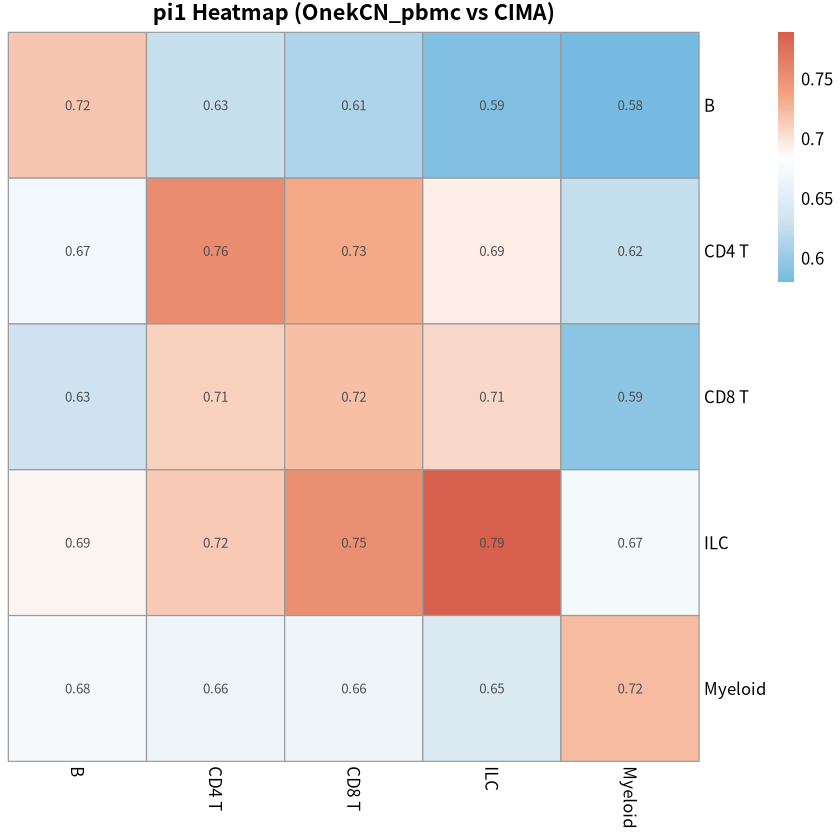

In [11]:
library(pheatmap)
p <- pheatmap(pi1_mat,
         color = colorRampPalette(c("#78BBE2","#D1E5F0","white","#F4A582","#D6604D"))(100),
         cluster_rows = FALSE,  # 不聚类，保持行列顺序
         cluster_cols = FALSE,
         display_numbers = TRUE, # 在格子中显示 π₁ 值
         number_format = "%.2f",
         main = "pi1 Heatmap (OnekCN_pbmc vs CIMA)")
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/pi1_OnekCN_pbmc_vs_CIMA.pdf',p)

#### OnekCN_pbmc VS AIDA

In [12]:
AIDA <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/AIDA.csv', head =T)
AIDA$L1 <- AIDA$AIDA_CellTypeAnnotation
ilc_types <- c('CD16+_NK','CD56+_NK')
cd4_types <- c('CD4+_T_cm','CD4+_T_cyt','CD4+_T_em','CD4+_T_naive','Treg')
cd8_types <- c('CD8+_T_GZMBhi','CD8+_T_GZMKhi','CD8+_T_naive','gdT_GZMBhi','gdT_GZMKhi','MAIT')
b_types <- c('atypical_B','memory_B_IGHMhi','memory_B_IGHMlo','naive_B')
myeloid_types <- c('CD14+_Monocyte','CD16+_Monocyte','cDC2')

AIDA$L1 <- ifelse(AIDA$L1 %in% ilc_types,"ILC", AIDA$L1)
AIDA$L1 <- ifelse(AIDA$L1 %in% cd4_types,"CD4 T", AIDA$L1)
AIDA$L1 <- ifelse(AIDA$L1 %in% cd8_types,"CD8 T", AIDA$L1)
AIDA$L1 <- ifelse(AIDA$L1 %in% b_types,"B", AIDA$L1)
AIDA$L1 <- ifelse(AIDA$L1 %in% myeloid_types,"Myeloid", AIDA$L1)

AIDA$Genetic.variant <- AIDA$Genetic.variant |> sub("^chr", "", x = _) |> gsub("_", ":", x = _)
colnames(AIDA)[colnames(AIDA) == "Gene"] <- "phenotype_id"
colnames(AIDA)[colnames(AIDA) == "Genetic.variant"] <- "variant_id"
AIDA <- subset(AIDA, eQTL_CellSubtype_FDR < 0.05)
AIDA

,AIDA_CellTypeAnnotation,variant_id,phenotype_id,eQTL_beta,eQTL_t.stat,eQTL_p.value,eQTL_CellSubtype_FDR,eigenMT_pvalue,eigenMT_tests,eigenMT_FDR,L1
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>
34,atypical_B,9:133255635:C:T,ABO,0.05896580,7.359656,2.97e-11,0.000000417,7.72000e-10,26,0.0000000192,B
70,atypical_B,19:54853020:T:G,AC008440.1,-0.02863677,-4.462328,1.90e-05,0.049466389,6.08278e-04,32,0.0044645970,B
83,atypical_B,2:117627042:G:A,AC009404.1,0.05867484,4.471806,1.83e-05,0.047964556,3.11186e-04,17,0.0026715880,B
94,atypical_B,16:10976466:C:T,AC010654.1,0.04764166,4.664665,8.41e-06,0.025539882,2.94243e-04,35,0.0025547900,B
129,atypical_B,18:58182932:C:T,AC027097.2,-0.06574669,-4.741847,6.12e-06,0.019875528,1.40831e-04,23,0.0013937960,B
130,atypical_B,16:78932323:C:T,AC027279.1,0.05643754,7.069070,1.29e-10,0.000001680,5.29000e-09,41,0.0000001190,B
137,atypical_B,8:142062851:T:G,AC040970.1,-0.03740229,-4.477754,1.79e-05,0.047082954,3.93282e-04,22,0.0032072200,B
182,atypical_B,15:65351600:A:G,AC103691.1,0.06656038,5.637018,1.25e-07,0.000830212,1.50000e-06,12,0.0000239000,B
206,atypical_B,7:155302116:T:C,AC144652.1,-0.07405487,-5.093673,1.39e-06,0.006083917,4.31000e-05,31,0.0005016950,B


In [13]:
library(qvalue)

calc_pi1_pair <- function(df1, df2, cell1, cell2){
  # 提取指定 cell type
  d1 <- df1 %>% filter(L1 == !!cell1)
  d2 <- df2 %>% filter(L1 == !!cell2)
  
  # 取共有的 (phenotype_id, variant_id)
  common <- merge(
    d1[, c("phenotype_id", "variant_id", "pval_nominal")],
    d2[, c("phenotype_id", "variant_id", "eQTL_p.value")],
    by = c("phenotype_id", "variant_id"),
    suffixes = c(".OnekCN_pbmc", "AIDA")
  )
  
  pvals <- common$pval_nominal
  
  # π₁ 估计
  qobj <- qvalue_truncp(pvals)
  pi1 <- 1 - qobj$pi0
  
  return(pi1)
}                                                                                                                                                                                                                                                                                                                                                                                                           

# 所有 cell type 列表
cells1 <- c('B','CD4 T','CD8 T','ILC','Myeloid')
cells2 <- c('B','CD4 T','CD8 T','ILC','Myeloid')

# 初始化矩阵
pi1_mat <- matrix(NA, nrow = length(cells1), ncol = length(cells2),
                  dimnames = list(cells1, cells2))

# 两两计算
for(i in seq_along(cells1)){
  for(j in seq_along(cells2)){
    pi1_mat[i,j] <- calc_pi1_pair(OnekCN_pbmc, AIDA, cells1[i], cells2[j])
  }
}

pi1_mat  # 行：OnekCN_pbmc cell type，列：Onek1k cell type

,B,CD4 T,CD8 T,ILC,Myeloid
B,0.4690529,0.3672317,0.3659551,0.3740919,0.3540572
CD4 T,0.3556966,0.4479379,0.4351346,0.4070705,0.3460825
CD8 T,0.3530520,0.4323056,0.4495669,0.4366267,0.3581506
ILC,0.4256080,0.4405608,0.4769413,0.4798219,0.4144966
Myeloid,0.4091445,0.4143054,0.3959022,0.3549381,0.4716068


Saving 7 x 7 in image


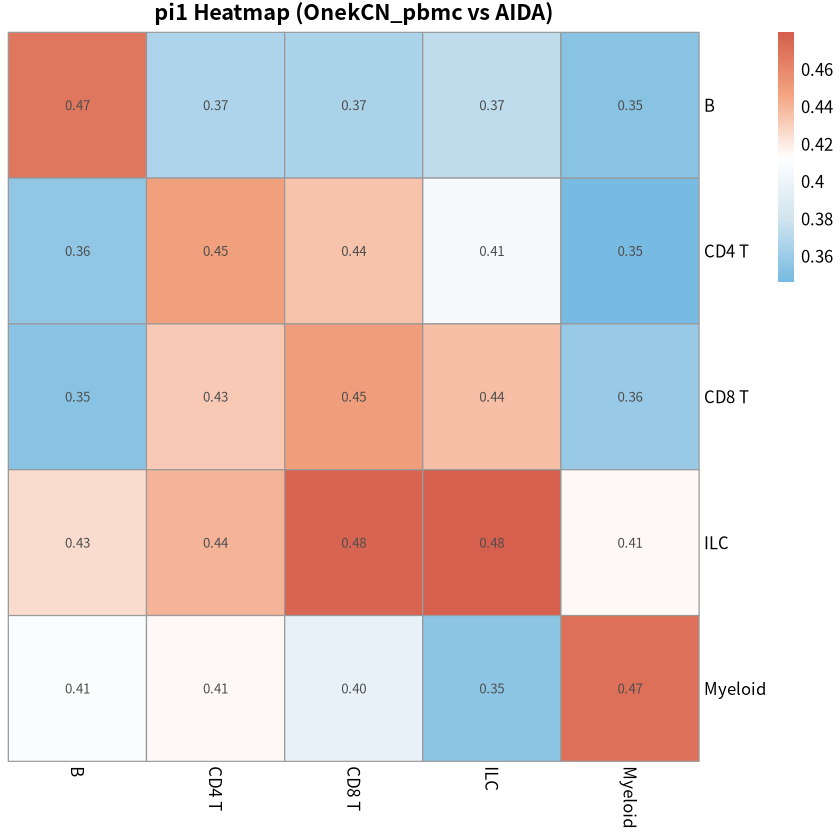

In [14]:
library(pheatmap)
p <- pheatmap(pi1_mat,
         color = colorRampPalette(c("#78BBE2","#D1E5F0","white","#F4A582","#D6604D"))(100),
         cluster_rows = FALSE,  # 不聚类，保持行列顺序
         cluster_cols = FALSE,
         display_numbers = TRUE, # 在格子中显示 π₁ 值
         number_format = "%.2f",
         main = "pi1 Heatmap (OnekCN_pbmc vs AIDA)")
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/pi1_OnekCN_pbmc_vs_AIDA.pdf',p)

#### OnekCN_pbmc VS Onek1k

In [15]:
Onek1k <- read.table('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/Onek1k.tsv', head =T, sep="\t")
Onek1k$L1 <- Onek1k$CELL_TYPE
ilc_types <- c('Natural Killer Recruiting Cell','Natural Killer Cell')
cd4_types <- c('CD4 Naive/Central memory T cell','CD4 SOX4 T cell','CD4 Effector memory/TEMRA')
cd8_types <- c('CD8 S100B T cell','CD8 Effector memory','CD8 Naive/Central memory T cell')
b_types <- c('Memory B Cell','Naïve/Immature B Cell','Plasma Cell')
myeloid_types <- c('Classic Monocyte','Dendritic Cell','Non-classic Monocyte')

Onek1k$L1 <- ifelse(Onek1k$L1 %in% ilc_types,"ILC", Onek1k$L1)
Onek1k$L1 <- ifelse(Onek1k$L1 %in% cd4_types,"CD4 T", Onek1k$L1)
Onek1k$L1 <- ifelse(Onek1k$L1 %in% cd8_types,"CD8 T", Onek1k$L1)
Onek1k$L1 <- ifelse(Onek1k$L1 %in% b_types,"B", Onek1k$L1)
Onek1k$L1 <- ifelse(Onek1k$L1 %in% myeloid_types,"Myeloid", Onek1k$L1)

Onek1k$variant_id <- paste0(Onek1k$CHR,":",Onek1k$POS,":",Onek1k$A1,":",Onek1k$A2)
colnames(Onek1k)[colnames(Onek1k) == "GENE"] <- "phenotype_id"
Onek1k

CELL_ID,CELL_TYPE,RSID,SNPID,phenotype_id,GENE_ID,CHR,POS,A1,A2,⋯,SPEARMANS_RHO,S_STATISTICS,P_VALUE,Q_VALUE,FDR,RSQUARE,GENOTYPED,ROUND,L1,variant_id
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
cd4nc,CD4 Naive/Central memory T cell,rs79010578,1:736289_A,RP11-206L10.9,ENSG00000237491,1,736289,T,A,⋯,0.1354816,136444808,2.045940e-05,2.828026e-03,2.523829e-02,0.84779,Imputed,1,CD4 T,1:736289:T:A
cd4nc,CD4 Naive/Central memory T cell,rs1891906,1:950243_C,ISG15,ENSG00000187608,1,950243,A,C,⋯,0.3327021,105317985,8.252290e-27,1.156738e-23,2.384248e-06,0.95444,Imputed,1,CD4 T,1:950243:A:C
cd4nc,CD4 Naive/Central memory T cell,rs57260149,1:1140290_C,TNFRSF18,ENSG00000186891,1,1140290,T,C,⋯,-0.1740004,185289578,4.074417e-08,9.655409e-06,1.784878e-04,0.95654,Imputed,1,CD4 T,1:1140290:T:C
cd4nc,CD4 Naive/Central memory T cell,rs307346,1:1260733_C,GLTPD1,ENSG00000224051,1,1260733,A,C,⋯,-0.1771180,185781627,2.303768e-08,5.656051e-06,3.573890e-05,0.99485,Imputed,1,CD4 T,1:1260733:A:C
cd4nc,CD4 Naive/Central memory T cell,rs2936661,1:1300946_A,MRPL20,ENSG00000242485,1,1300946,G,A,⋯,-0.1825076,186632255,8.392422e-09,2.184810e-06,2.384248e-06,0.97300,Imputed,1,CD4 T,1:1300946:G:A
cd4nc,CD4 Naive/Central memory T cell,rs904586,1:1430584_C,ATAD3C,ENSG00000215915,1,1430584,T,C,⋯,0.1307779,137187175,3.946017e-05,5.042102e-03,3.822900e-02,0.82905,Imputed,1,CD4 T,1:1430584:T:C
cd4nc,CD4 Naive/Central memory T cell,rs12735861,1:1562895_T,MIB2,ENSG00000197530,1,1562895,C,T,⋯,-0.2440818,196350355,8.721559e-15,5.160831e-12,2.384248e-06,0.85902,Imputed,1,CD4 T,1:1562895:C:T
cd4nc,CD4 Naive/Central memory T cell,rs9442411,1:1619767_T,CDK11A,ENSG00000008128,1,1619767,C,T,⋯,-0.1480648,181196226,3.166954e-06,5.358130e-04,5.284723e-03,0.99706,Genotyped,1,CD4 T,1:1619767:C:T
cd4nc,CD4 Naive/Central memory T cell,rs9442411,1:1619767_T,MMP23B,ENSG00000189409,1,1619767,C,T,⋯,-0.1378395,179582392,1.459834e-05,2.093437e-03,1.971423e-02,0.99706,Genotyped,1,CD4 T,1:1619767:C:T


In [16]:
library(qvalue)

calc_pi1_pair <- function(df1, df2, cell1, cell2){
  # 提取指定 cell type
  d1 <- df1 %>% filter(L1 == !!cell1)
  d2 <- df2 %>% filter(L1 == !!cell2)
  
  # 取共有的 (phenotype_id, variant_id)
  common <- merge(
    d1[, c("phenotype_id", "variant_id", "pval_nominal")],
    d2[, c("phenotype_id", "variant_id", "P_VALUE")],
    by = c("phenotype_id", "variant_id"),
    suffixes = c(".OnekCN_pbmc", ".Onek1k")
  )
  
  pvals <- common$pval_nominal
  
  # π₁ 估计
  qobj <- qvalue_truncp(pvals)
  pi1 <- 1 - qobj$pi0
  
  return(pi1)
}                                                                                                                                                                                                                                                                                                                                                                                                           

# 所有 cell type 列表
cells1 <- c('B','CD4 T','CD8 T','ILC','Myeloid')
cells2 <- c('B','CD4 T','CD8 T','ILC','Myeloid')

# 初始化矩阵
pi1_mat <- matrix(NA, nrow = length(cells1), ncol = length(cells2),
                  dimnames = list(cells1, cells2))

# 两两计算
for(i in seq_along(cells1)){
  for(j in seq_along(cells2)){
    pi1_mat[i,j] <- calc_pi1_pair(OnekCN_pbmc, Onek1k, cells1[i], cells2[j])
  }
}

pi1_mat  # 行：OnekCN_pbmc cell type，列：Onek1k cell type

,B,CD4 T,CD8 T,ILC,Myeloid
B,0.3874170,0.5588717,0.5321565,0.3900104,0.36929053
CD4 T,0.6277540,0.4875203,0.6705071,0.7991275,0.48936024
CD8 T,0.6678451,0.4764130,0.5952085,0.3036604,0.27485790
ILC,0.3203837,0.4735336,0.4827823,0.5048105,0.09335795
Myeloid,0.6132882,0.4237434,0.3912960,0.3424456,0.70789719


Saving 7 x 7 in image


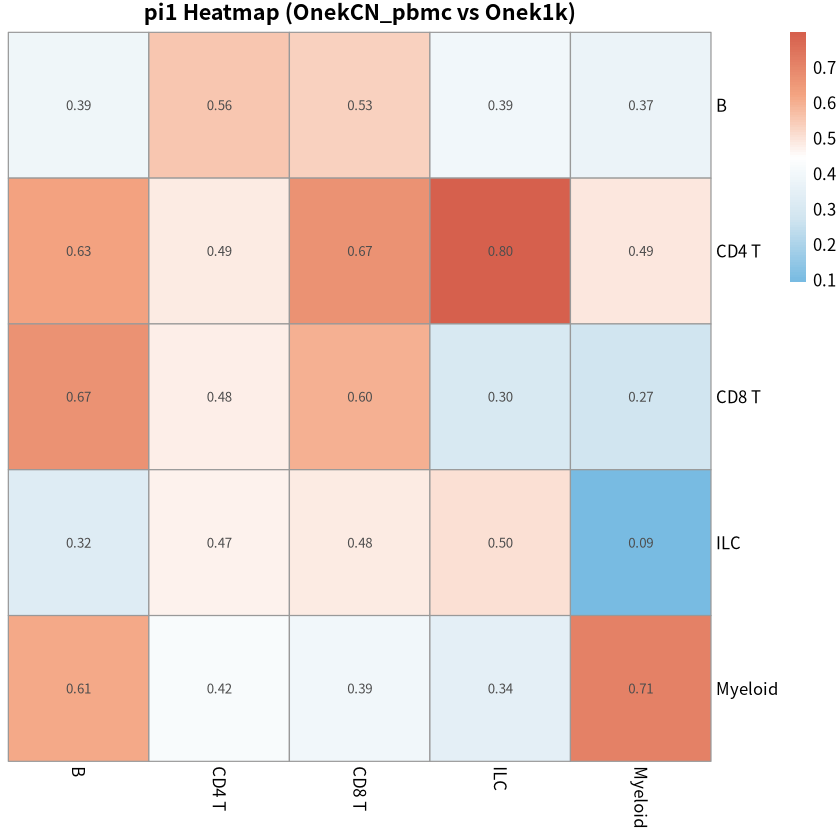

In [17]:
library(pheatmap)
p <- pheatmap(pi1_mat,
         color = colorRampPalette(c("#78BBE2","#D1E5F0","white","#F4A582","#D6604D"))(100),
         cluster_rows = FALSE,  # 不聚类，保持行列顺序
         cluster_cols = FALSE,
         display_numbers = TRUE, # 在格子中显示 π₁ 值
         number_format = "%.2f",
         main = "pi1 Heatmap (OnekCN_pbmc vs Onek1k)")
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/pi1_OnekCN_pbmc_vs_Onek1k.pdf',p)

#### OnekCN_neutrophils VS EUR101

In [18]:
OnekCN_neutrophils$L1 <- OnekCN_neutrophils$celltype
Basophils_types <- c("Basophils")
mature_neutrophils_types <- c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs')
immature_neutrophils_types <- c('MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs','Proliferative mLDNs')

OnekCN_neutrophils$L1 <- ifelse(OnekCN_neutrophils$L1 %in% Basophils_types,"Basophils", OnekCN_neutrophils$L1)
OnekCN_neutrophils$L1 <- ifelse(OnekCN_neutrophils$L1 %in% mature_neutrophils_types,"mature_neutrophils", OnekCN_neutrophils$L1)
OnekCN_neutrophils$L1 <- ifelse(OnekCN_neutrophils$L1 %in% immature_neutrophils_types,"immature_neutrophils", OnekCN_neutrophils$L1)

OnekCN_neutrophils

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype,L1
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
LINC01409,1:13868:A:G,-764880,-796197,0.3467456,481,586,0.95130062,0.0029966952,0.04905113,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:16949:A:C,-761799,-793116,0.1278107,206,216,0.06953613,0.1323362440,0.07281499,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:19342:G:A,-759406,-790723,0.1183432,190,200,0.95934296,-0.0037925104,0.07437088,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:20250:T:C,-758498,-789815,0.2769231,405,468,0.84240332,0.0104769524,0.05267797,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:54421:A:G,-724327,-755644,0.1390533,217,235,0.69067802,-0.0272205286,0.06837895,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:57158:G:C,-721590,-752907,0.1272189,212,215,0.89796043,0.0097886454,0.07630675,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:58176:G:A,-720572,-751889,0.3473373,490,587,0.48103575,-0.0355024710,0.05035975,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:59193:T:G,-719555,-750872,0.1414201,222,239,0.63844928,-0.0320551358,0.06819477,ALPL- MARCKS- NDNs,mature_neutrophils
LINC01409,1:59615:C:T,-719133,-750450,0.1461539,229,247,0.77458762,-0.0192876048,0.06732641,ALPL- MARCKS- NDNs,mature_neutrophils


In [19]:
EUR101 <- read.csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/EUR101.csv', head =T)
EUR101$L1 <- 'mature_neutrophils'
EUR101$variant_id <- paste0(EUR101$Chromosome,":",EUR101$Position,":",EUR101$REF,":",EUR101$ALT)
EUR101$phenotype_id <- EUR101$genename
EUR101

rsID,Chromosome,Position,REF,ALT,gene,statistic,pvalue,FDR,beta,R2..Var.explained.,genename,L1,variant_id,phenotype_id
<chr>,<int>,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
rs1000431,1,27898603,C,A,3420561,11.311591,1.45000e-18,9.820000e-15,0.40358205,0.5017370,RPA2,mature_neutrophils,1:27898603:C:A,RPA2
rs10012416,4,1330558,G,A,4210653,9.307637,1.43000e-14,3.740000e-11,0.55616988,0.4554239,CRIPAK,mature_neutrophils,4:1330558:G:A,CRIPAK
rs10014278,4,83246831,C,T,630619,-4.397734,3.19000e-05,8.702704e-03,-0.21150090,0.1573368,HPSE,mature_neutrophils,4:83246831:C:T,HPSE
rs10026792,4,2860463,G,A,3870577,-4.164332,7.53000e-05,1.757067e-02,-0.07925069,0.1536241,MFSD10,mature_neutrophils,4:2860463:G:A,MFSD10
rs10034537,4,87370995,G,A,6280008,3.976213,1.47690e-04,3.012252e-02,0.20839852,0.1258485,HSD17B11,mature_neutrophils,4:87370995:G:A,HSD17B11
rs10035183,5,177057983,A,G,2970121,4.081650,1.01461e-04,2.238584e-02,0.16663953,0.1467309,MXD3,mature_neutrophils,5:177057983:A:G,MXD3
rs10039522,5,96655165,G,A,3990112,5.916526,6.90000e-08,4.160000e-05,0.18296225,0.2578683,CAST,mature_neutrophils,5:96655165:G:A,CAST
rs10047656,12,129140724,G,A,6650465,3.829310,2.46786e-04,4.473485e-02,0.21435939,0.1289934,SLC15A4,mature_neutrophils,12:129140724:G:A,SLC15A4
rs10051822,5,177308186,G,C,6590669,4.060126,1.09594e-04,2.383356e-02,0.11084957,0.1431211,RAB24,mature_neutrophils,5:177308186:G:C,RAB24


In [20]:
library(qvalue)

calc_pi1_pair <- function(df1, df2, cell1, cell2){
  # 提取指定 cell type
  d1 <- df1 %>% filter(L1 == !!cell1)
  d2 <- df2 %>% filter(L1 == !!cell2)
  
  # 取共有的 (phenotype_id, variant_id)
  common <- merge(
    d1[, c("phenotype_id", "variant_id", "pval_nominal")],
    d2[, c("phenotype_id", "variant_id", "pvalue")],
    by = c("phenotype_id", "variant_id")
  )
  
  pvals <- common$pval_nominal
  
  # π₁ 估计
  qobj <- qvalue_truncp(pvals)
  pi1 <- 1 - qobj$pi0
  
  return(pi1)
}                                                                                                                                                                                                                                                                                                                                                                                                           

# 所有 cell type 列表
cells1 <- c('mature_neutrophils','immature_neutrophils','Basophils')
cells2 <- c('mature_neutrophils')

# 初始化矩阵
pi1_mat <- matrix(NA, nrow = length(cells1), ncol = length(cells2),
                  dimnames = list(cells1, cells2))

# 两两计算
for(i in seq_along(cells1)){
  for(j in seq_along(cells2)){
    pi1_mat[i,j] <- calc_pi1_pair(OnekCN_neutrophils, EUR101, cells1[i], cells2[j])
  }
}

pi1_mat  # 行：OnekCN_pbmc cell type，列：Onek1k cell type

,mature_neutrophils
mature_neutrophils,0.61008548
immature_neutrophils,0.17950199
Basophils,0.06458235


Saving 7 x 7 in image


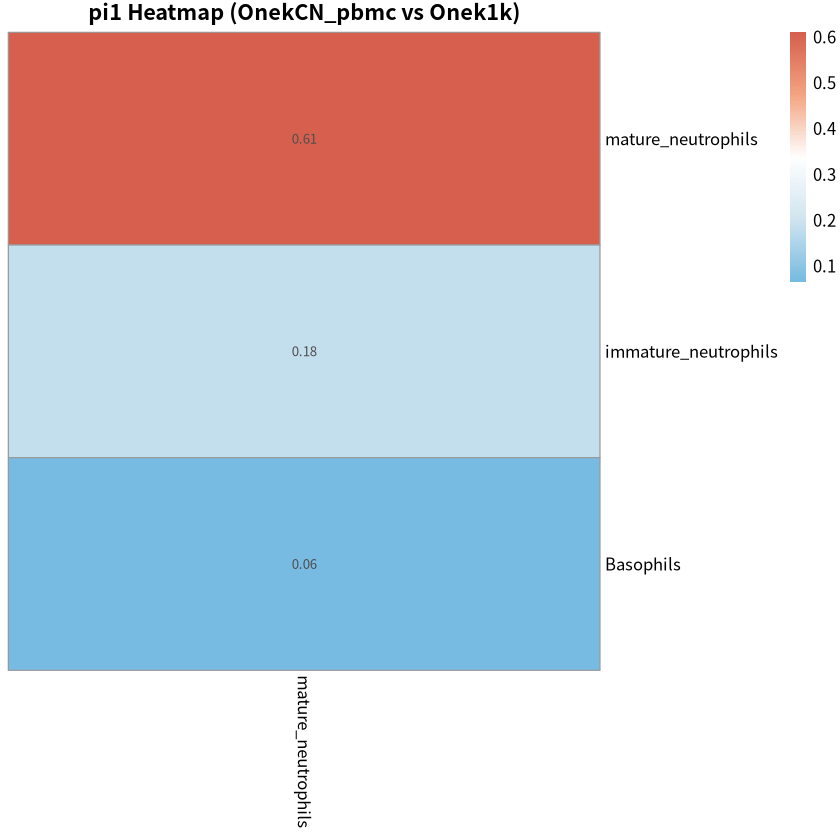

In [21]:
library(pheatmap)
p <- pheatmap(pi1_mat,
         color = colorRampPalette(c("#78BBE2","#D1E5F0","white","#F4A582","#D6604D"))(100),
         cluster_rows = FALSE,  # 不聚类，保持行列顺序
         cluster_cols = FALSE,
         display_numbers = TRUE, # 在格子中显示 π₁ 值
         number_format = "%.2f",
         main = "pi1 Heatmap (OnekCN_pbmc vs Onek1k)")
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/Database/pi1_OnekCN_neutrophils_vs_EUR101.pdf',p)

### 共享顺式 eQTL 的遗传效应相关性

#### OnekCN_pbmc VS CIMA

In [19]:
OnekCN_pbmc

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype,L1
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
LINC01409,1:722408:G:C,-56340,-87657,0.1923523,299,332,7.801378e-01,0.01536029,0.05500862,Adaptive NK cells,ILC
LINC01409,1:727477:G:A,-51271,-82588,0.2079954,321,359,3.625698e-01,0.04851910,0.05325894,Adaptive NK cells,ILC
LINC01409,1:727717:G:C,-51031,-82348,0.2056779,317,355,5.380251e-01,0.03285443,0.05332908,Adaptive NK cells,ILC
LINC01409,1:732994:G:A,-45754,-77071,0.2392816,364,413,4.044052e-02,-0.10461613,0.05096809,Adaptive NK cells,ILC
LINC01409,1:733601:T:C,-45147,-76464,0.2010429,312,347,1.471227e-01,-0.07859480,0.05415897,Adaptive NK cells,ILC
LINC01409,1:766566:A:G,-12182,-43499,0.1726535,285,298,1.182392e-04,0.23351580,0.06035543,Adaptive NK cells,ILC
LINC01409,1:768987:T:C,-9761,-41078,0.1720742,285,297,1.638191e-04,0.22986200,0.06069363,Adaptive NK cells,ILC
LINC01409,1:769828:G:C,-8920,-40237,0.1714948,284,296,1.612760e-04,0.23018126,0.06071447,Adaptive NK cells,ILC
LINC01409,1:770988:A:G,-7760,-39077,0.2630359,400,454,4.298507e-01,-0.03942816,0.04991850,Adaptive NK cells,ILC


In [22]:
CIMA

,X,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,slope_se,pval_perm,pval_beta,celltype,study_wise_qval,study_wise_nominal_threshold,A1.ALT.effect.allele.,A2.REF.,analysis,L1
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,LINC01128,2344,1.029518,146.58803,297.0967,6.708564e-08,1:814733:A:T,-10405,-10405,⋯,0.10313909,0.00009999,6.909136e-06,Atypical_Bm_ITGAX,6.252067e-05,9.086377e-05,T,A,cis-eQTL,B
2,1,UBE2J2,3402,1.049307,210.10033,294.1663,5.556540e-05,1:1329973:GCGTGTGCCATGCA:G,56088,56088,⋯,0.07831303,0.00769923,9.120395e-03,Atypical_Bm_ITGAX,4.137411e-02,6.940499e-05,G,GCGTGTGCCATGCA,cis-eQTL,B
3,2,SSU72,4096,1.053009,308.96730,300.3712,3.530564e-05,1:1538787:A:G,-36076,-36076,⋯,0.09141989,0.00729927,8.341344e-03,Atypical_Bm_ITGAX,3.839333e-02,4.798780e-05,G,A,cis-eQTL,B
4,3,SLC35E2B,4245,1.040838,317.42334,302.7886,6.500860e-14,1:1646352:A:C,-46443,-46443,⋯,0.08075760,0.00009999,7.422213e-12,Atypical_Bm_ITGAX,1.377836e-10,4.421236e-05,C,A,cis-eQTL,B
5,4,CDK11A,4245,1.061452,303.00452,297.5697,4.930235e-05,1:1687061:C:T,-37296,-37296,⋯,0.06234498,0.00899910,1.114399e-02,Atypical_Bm_ITGAX,4.876636e-02,5.079840e-05,T,C,cis-eQTL,B
6,5,SLC35E2A,4245,1.031444,332.26532,304.9197,2.041432e-18,1:1660318:C:T,-85681,-85681,⋯,0.06994368,0.00009999,2.231382e-16,Atypical_Bm_ITGAX,6.097264e-15,4.045071e-05,T,C,cis-eQTL,B
7,6,CEP104,5730,1.053672,524.15173,309.9714,7.046991e-19,1:3813871:T:C,-43343,-43343,⋯,0.05781302,0.00009999,5.357085e-17,Atypical_Bm_ITGAX,1.532077e-15,2.837210e-05,C,T,cis-eQTL,B
8,7,C1orf174,5796,1.039989,497.33353,307.2871,5.461152e-09,1:3887191:T:C,-13102,-13102,⋯,0.06172594,0.00009999,1.598832e-06,Atypical_Bm_ITGAX,1.590033e-05,2.811018e-05,C,T,cis-eQTL,B
9,8,UQCRHL,2981,1.045385,231.19757,304.3138,5.596262e-05,1:16370539:A:AT,561191,561191,⋯,0.07374086,0.00999900,1.034565e-02,Atypical_Bm_ITGAX,4.587640e-02,6.196658e-05,AT,A,cis-eQTL,B


In [67]:
AIDA

,AIDA_CellTypeAnnotation,variant_id,phenotype_id,eQTL_beta,eQTL_t.stat,eQTL_p.value,eQTL_CellSubtype_FDR,eigenMT_pvalue,eigenMT_tests,eigenMT_FDR,L1
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>
34,atypical_B,9:133255635:C:T,ABO,0.05896580,7.359656,2.97e-11,0.000000417,7.72000e-10,26,0.0000000192,B
70,atypical_B,19:54853020:T:G,AC008440.1,-0.02863677,-4.462328,1.90e-05,0.049466389,6.08278e-04,32,0.0044645970,B
83,atypical_B,2:117627042:G:A,AC009404.1,0.05867484,4.471806,1.83e-05,0.047964556,3.11186e-04,17,0.0026715880,B
94,atypical_B,16:10976466:C:T,AC010654.1,0.04764166,4.664665,8.41e-06,0.025539882,2.94243e-04,35,0.0025547900,B
129,atypical_B,18:58182932:C:T,AC027097.2,-0.06574669,-4.741847,6.12e-06,0.019875528,1.40831e-04,23,0.0013937960,B
130,atypical_B,16:78932323:C:T,AC027279.1,0.05643754,7.069070,1.29e-10,0.000001680,5.29000e-09,41,0.0000001190,B
137,atypical_B,8:142062851:T:G,AC040970.1,-0.03740229,-4.477754,1.79e-05,0.047082954,3.93282e-04,22,0.0032072200,B
182,atypical_B,15:65351600:A:G,AC103691.1,0.06656038,5.637018,1.25e-07,0.000830212,1.50000e-06,12,0.0000239000,B
206,atypical_B,7:155302116:T:C,AC144652.1,-0.07405487,-5.093673,1.39e-06,0.006083917,4.31000e-05,31,0.0005016950,B


In [87]:
d1 <- OnekCN_pbmc %>% filter(celltype == 'Core classical monocytes')
d2 <- AIDA %>% filter(AIDA_CellTypeAnnotation == 'CD14+_Monocyte')

In [88]:
common <- merge(
    d1[, c("phenotype_id", "variant_id",'pval_nominal', "slope",'slope_se')],
    d2[, c("phenotype_id", "variant_id",'eQTL_p.value', "eQTL_beta")],
    by = c("phenotype_id", "variant_id"),
    suffixes = c(".OnekCN_pbmc", ".AIDA")
  )

In [89]:
common

phenotype_id,variant_id,pval_nominal,slope,eQTL_p.value,eQTL_beta
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,19:58352784:T:C,2.266407e-60,-1.02145660,2.63000e-38,0.134233488
A1BG-AS1,19:58352784:T:C,9.928797e-60,-1.04097307,1.00000e-12,0.016539969
AAK1,2:69681403:T:C,2.510320e-03,-0.12330742,5.49000e-06,-0.023293916
AASDH,4:56323332:G:A,3.619023e-46,0.36807710,4.01000e-08,-0.011276493
AATBC,21:43795170:A:G,3.625463e-05,0.09716187,4.52000e-05,-0.012491289
ABCA7,19:1099507:G:T,9.134999e-02,-0.04695364,2.05808e-04,-0.013954387
ABCC10,6:43292274:A:C,1.435841e-03,-0.10265870,2.68541e-04,-0.007123304
ABCC3,17:50635819:A:G,5.633295e-43,0.89962178,6.02000e-54,-0.068669689
ABCC4,13:95239178:A:T,2.481118e-01,0.07684150,3.08417e-04,0.006261135


In [90]:
corr <- cor(common$slope, common$eQTL_beta, use = "complete.obs")
corr

[1] 0.2447887

In [24]:
plot_corr_scatter <- function(df1, df2, cell1, cell2, save.dir = NULL) {
  # 提取指定 cell type
  d1 <- df1 %>% filter(celltype == !!cell1)
  d2 <- df2 %>% filter(celltype == !!cell2)
  
  # 取共有的 (phenotype_id, variant_id)
  common <- merge(
    d1[, c("phenotype_id", "variant_id", "slope")],
    d2[, c("phenotype_id", "variant_id", "slope")],
    by = c("phenotype_id", "variant_id"),
    suffixes = c(".OnekCN_pbmc", ".CIMA")
  )
  
  # 计算相关性
  corr <- cor(common$slope.OnekCN_pbmc, common$slope.CIMA, use = "complete.obs")
  
  # 绘制散点图 (修正标题)
  p <- ggplot(common, aes(x = slope.OnekCN_pbmc, y = slope.CIMA)) +
    geom_point(alpha = 0.4, size = 1) +
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    labs(title = paste0(cell1, " (OnekCN_pbmc) vs ", cell2, " (CIMA)\nCorrelation = ", round(corr, 3)), x = "Beta (OnekCN_pbmc)", y = "Beta (CIMA)") +
    theme_bw()
  
  # 保存文件 (使用正确的细胞名)
  if(!is.null(save.dir)){
    fname <- paste0(save.dir, "/", gsub(" ", "_", cell1), "_vs_",gsub(" ", "_", cell2), ".pdf")
    ggsave(fname, plot = p, width = 8, height = 6)
  }
  
  return(p)
}

# 定义一一对应的细胞类型
cell1_vec <- c('Naïve CD4+ T cells', 'Naïve CD8+ T cells', 'CD56dim NK cells', 'Naïve B cells', 'Core classical monocytes')
cell2_vec <- c('CD4_Tn_CCR7', 'CD8_Tn_CCR7', 'Mature_NK_dim_FCGR3A', 'Bn_TCL1A', 'cMono_CD14')

# 输出目录
save.dir <- "/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/Database"

# 批量生成散点图 (同时迭代两个向量)
for(i in seq_along(cell1_vec)) {
  plot_corr_scatter(
    df1 = OnekCN_pbmc, 
    df2 = CIMA,
    cell1 = cell1_vec[i],
    cell2 = cell2_vec[i],
    save.dir = save.dir
  )
}

ERROR: Error in cor(common$slope.OnekCN_pbmc, common$slope.CIMA, use = "complete.obs"): 不存在完的一对


#### OnekCN_pbmc VS AIDA

#### OnekCN_pbmc VS Onek1k

In [ ]:
OnekCN_pbmc

In [ ]:
Onek1k

In [ ]:
# 计算并绘制散点图
plot_corr_scatter <- function(df1, df2, cell, save.dir=NULL){
  # 提取指定 cell type
  d1 <- df1 %>% filter(L1 == !!cell)
  d2 <- df2 %>% filter(L1 == !!cell)
  
  # 取共有的 (phenotype_id, variant_id)
  common <- merge(
    d1[, c("phenotype_id", "variant_id", "beta")],
    d2[, c("phenotype_id", "variant_id", "BETA")],
    by = c("phenotype_id", "variant_id"),
    suffixes = c(".OnekCN_pbmc", ".Onek1k")
  )
  
  # 计算相关性
  corr <- cor(common$beta.OnekCN_pbmc, common$BETA.Onek1k, use = "complete.obs")
  
  # 绘制散点图
  p <- ggplot(common, aes(x = beta.OnekCN_pbmc, y = BETA.Onek1k)) +
    geom_point(alpha = 0.4, size = 1) +
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    labs(title = paste0(cell, " vs ", cell, "\nCorrelation = ", round(corr, 3)),
         x = "Beta (OnekCN_pbmc)", y = "Beta (Onek1k)") +
    theme_bw()
  
  # 保存文件
  if(!is.null(save.dir)){
    fname <- paste0(save.dir, "/", gsub(" ", "OnekCN_pbmc_", cell), "_vs_", gsub(" ", "Onek1k_", cell), ".pdf")
    ggsave(fname, plot = p)
  }
  
  return(p)
}

# 定义细胞类型
cells <- c('CD4 T','CD8 T','ILC','Myeloid')

# 输出目录
save.dir <- "/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/Database"
dir.create(save.dir, showWarnings = FALSE)

# 批量生成散点图
for(cell in cells){
    plot_corr_scatter(OnekCN_pbmc, Onek1k, cell, save.dir)
}

#### OnekCN_neutrophils VS EUR101

In [72]:
OnekCN_neutrophils

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,celltype,L1
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GNB1,1:785417:G:A,-999869,-1106875,0.1715976,278,290,0.6652599,0.021197226,0.04897380,Basophils,Basophils
GNB1,1:788511:G:C,-996775,-1103781,0.2029586,320,343,0.3547549,-0.042325459,0.04570987,Basophils,Basophils
GNB1,1:790121:G:A,-995165,-1102171,0.1343195,217,227,0.7576933,0.016310193,0.05284879,Basophils,Basophils
GNB1,1:790124:T:A,-995162,-1102168,0.1372781,223,232,0.9636233,-0.002407532,0.05277142,Basophils,Basophils
GNB1,1:790126:T:G,-995160,-1102166,0.1479290,237,250,0.4736863,-0.036339525,0.05069382,Basophils,Basophils
GNB1,1:791101:T:G,-994185,-1101191,0.1035503,167,175,0.1554417,-0.083639570,0.05882028,Basophils,Basophils
GNB1,1:792275:C:T,-993011,-1100017,0.1644970,268,278,0.6482478,0.022851503,0.05007176,Basophils,Basophils
GNB1,1:792779:C:T,-992507,-1099513,0.1704142,275,288,0.6791543,0.020230137,0.04889184,Basophils,Basophils
GNB1,1:792862:C:G,-992424,-1099430,0.1644970,268,278,0.6482478,0.022851503,0.05007176,Basophils,Basophils


In [73]:
EUR101

rsID,Chromosome,Position,REF,ALT,gene,statistic,pvalue,FDR,beta,R2..Var.explained.,genename,L1,variant_id,phenotype_id
<chr>,<int>,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
rs1000431,1,27898603,C,A,3420561,11.311591,1.45000e-18,9.820000e-15,0.40358205,0.5017370,RPA2,mature_neutrophils,1:27898603:C:A,RPA2
rs10012416,4,1330558,G,A,4210653,9.307637,1.43000e-14,3.740000e-11,0.55616988,0.4554239,CRIPAK,mature_neutrophils,4:1330558:G:A,CRIPAK
rs10014278,4,83246831,C,T,630619,-4.397734,3.19000e-05,8.702704e-03,-0.21150090,0.1573368,HPSE,mature_neutrophils,4:83246831:C:T,HPSE
rs10026792,4,2860463,G,A,3870577,-4.164332,7.53000e-05,1.757067e-02,-0.07925069,0.1536241,MFSD10,mature_neutrophils,4:2860463:G:A,MFSD10
rs10034537,4,87370995,G,A,6280008,3.976213,1.47690e-04,3.012252e-02,0.20839852,0.1258485,HSD17B11,mature_neutrophils,4:87370995:G:A,HSD17B11
rs10035183,5,177057983,A,G,2970121,4.081650,1.01461e-04,2.238584e-02,0.16663953,0.1467309,MXD3,mature_neutrophils,5:177057983:A:G,MXD3
rs10039522,5,96655165,G,A,3990112,5.916526,6.90000e-08,4.160000e-05,0.18296225,0.2578683,CAST,mature_neutrophils,5:96655165:G:A,CAST
rs10047656,12,129140724,G,A,6650465,3.829310,2.46786e-04,4.473485e-02,0.21435939,0.1289934,SLC15A4,mature_neutrophils,12:129140724:G:A,SLC15A4
rs10051822,5,177308186,G,C,6590669,4.060126,1.09594e-04,2.383356e-02,0.11084957,0.1431211,RAB24,mature_neutrophils,5:177308186:G:C,RAB24


In [118]:
cell <- 'mature_neutrophils'
d1 <- OnekCN_neutrophils %>% filter(L1 == !!cell)
d2 <- EUR101 %>% filter(L1 == !!cell)

In [119]:
common <- merge(
    d1[, c("phenotype_id", "variant_id", 'pval_nominal',"slope")],
    d2[, c("phenotype_id", "variant_id", 'pvalue', "beta")],
    by = c("phenotype_id", "variant_id"),
    suffixes = c(".OnekCN_nue", ".EUR101")
  )

In [120]:
common

phenotype_id,variant_id,pval_nominal,slope,pvalue,beta
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AATK,17:81149334:C:T,1.268811e-130,-0.88652492,1.48e-07,-0.08959702
AATK,17:81149334:C:T,2.325505e-101,-0.78523058,1.48e-07,-0.08959702
AATK,17:81149334:C:T,5.338747e-122,-0.88846451,1.48e-07,-0.08959702
AATK,17:81149334:C:T,2.844521e-133,-0.86870533,1.48e-07,-0.08959702
AATK,17:81149334:C:T,2.363563e-133,-0.83927327,1.48e-07,-0.08959702
ABCC5,3:183913574:T:C,7.637494e-18,-0.33256575,1.21e-10,-0.27336508
ABCC5,3:183913574:T:C,6.140306e-16,-0.29056612,1.21e-10,-0.27336508
ABCC5,3:183913574:T:C,5.799454e-13,-0.30151039,1.21e-10,-0.27336508
ABCC5,3:183913574:T:C,1.905062e-14,-0.31015781,1.21e-10,-0.27336508


In [122]:
common_min <- common %>%
  group_by(phenotype_id) %>%
  slice_min(order_by = pval_nominal, n = 1) %>%
  ungroup()
common_min

phenotype_id,variant_id,pval_nominal,slope,pvalue,beta
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AATK,17:81149334:C:T,2.363563e-133,-0.83927327,1.48000e-07,-0.08959702
ABCC5,3:183935144:G:C,7.076629e-103,-0.65726161,2.89000e-11,-0.21670885
ABR,17:1616943:C:A,2.940618e-01,-0.02781085,9.14000e-05,0.06825157
ACCS,11:44066439:G:T,2.463013e-195,1.08926499,4.01000e-48,1.03812256
ACP6,1:147647471:G:A,8.200477e-25,-0.31668177,4.98000e-06,-0.11965657
ACSL5,10:112414673:A:C,6.507040e-86,-0.80003411,4.30000e-14,-0.16867618
ACTA2,10:88996308:C:T,1.290944e-110,-0.72167337,7.80000e-18,-0.27787312
ACTN1,14:69349935:T:C,6.642486e-02,-0.07807586,1.52427e-04,0.09364366
ADARB2,10:1240467:C:A,9.755597e-07,0.24705979,1.16000e-15,0.35692715


In [124]:
corr <- cor(common_min$slope, common_min$beta, method = "s")
corr

[1] 0.3406672

`geom_smooth()` using formula = 'y ~ x'


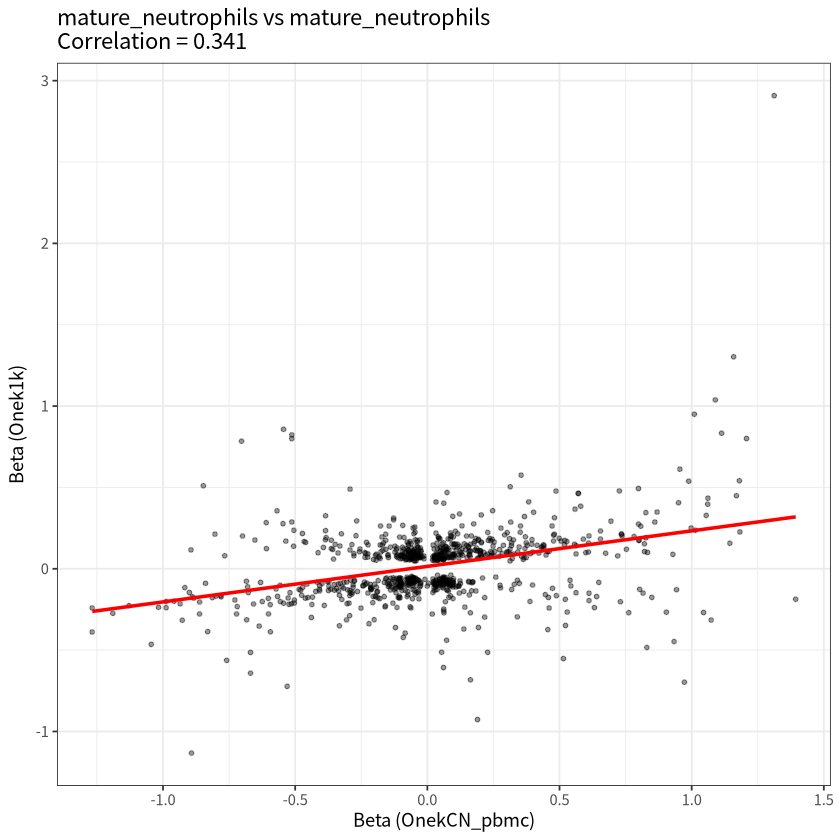

In [125]:
p <- ggplot(common_min, aes(x = slope, y = beta)) +
    geom_point(alpha = 0.4, size = 1) +
    geom_smooth(method = "lm", se = FALSE, color = "red") +
    labs(title = paste0(cell, " vs ", cell, "\nCorrelation = ", round(corr, 3)),
         x = "Beta (OnekCN_pbmc)", y = "Beta (Onek1k)") +
    theme_bw()
p

In [106]:
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/Database/cor_OnekCN_neutrophils_vs_EUR101.pdf',p)

Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'
